# Evaluation notebook for **Results** slide in the final presentation

This notebook uses the project modules already in this repository to fill the **Results** slide in the final presentation. It will:

- load the shared vocabulary and the trained `best.pt` checkpoint
- recreate the same seeded image-level test split used by training/evaluation
- generate one greedy caption per test image
- compute corpus BLEU-1 to BLEU-4 with the same smoothing as `evaluate.py`
- export slide-ready BLEU tables, example captions, and example images

## Before running

Run this from the repository root, after training has produced:

- `outputs/vocab.pkl`
- `outputs/checkpoints/best.pt`

If either file is missing, run `python train.py` first. The dataset is resolved through `config.py`; by default `kagglehub` downloads Flickr8k lazily on first use.

In [4]:
from pathlib import Path
import math
import shutil
import sys
import textwrap

import numpy as np
import pandas as pd
import torch
from IPython.display import Markdown, display
from PIL import Image
import matplotlib.pyplot as plt

PROJECT_ROOT = Path.cwd().resolve()
if not (PROJECT_ROOT / "evaluate.py").exists():
    raise FileNotFoundError(
        "This notebook should be run from the project root "
        "(the directory containing evaluate.py)."
    )

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

EVALUATION_DIR = PROJECT_ROOT / "outputs" / "evaluation"
EVALUATION_DIR.mkdir(parents=True, exist_ok=True)

VOCAB_PATH = PROJECT_ROOT / "outputs" / "vocab.pkl"
CHECKPOINT_PATH = PROJECT_ROOT / "outputs" / "checkpoints" / "best.pt"

# Quick smoke test while dev. the notebook; can stay None for the final gen.
EVALUATION_LIMIT = None

EXAMPLE_IMAGE_NAMES = [] # Optional; specific image file names for fixed examples.
NUM_EXAMPLES_TO_SHOW = 4

print("Project root:", PROJECT_ROOT)
print("Evaluation outputs:", EVALUATION_DIR)

Project root: /Users/emanuelklatzer/Projects/03_TUW/DL_image-captioning-project
Evaluation outputs: /Users/emanuelklatzer/Projects/03_TUW/DL_image-captioning-project/outputs/evaluation


In [5]:
from config import DEVICE, MAX_CAPTION_LENGTH, get_captions_file, get_images_dir
from dataset import build_transform, split_by_image
from evaluate import (
    align,
    build_references,
    compute_bleu,
    generate_hypotheses,
    load_model_from_checkpoint,
)
from vocabulary import Vocabulary

print("Evaluation device:", DEVICE)

Evaluation device: mps


## 1. Load trained artifacts

This section fails early with a clear message if the final training run has not produced the vocabulary/checkpoint yet.

In [6]:
missing = [path for path in [VOCAB_PATH, CHECKPOINT_PATH] if not path.exists()]
if missing:
    missing_text = "\n".join(f"- {path}" for path in missing)
    raise FileNotFoundError(
        "Missing trained artifact(s):\n"
        f"{missing_text}\n\n"
        "Run `python train.py` from the repository root, then rerun this notebook."
    )

vocab = Vocabulary.load(VOCAB_PATH)
checkpoint_info = torch.load(CHECKPOINT_PATH, map_location="cpu")

model = load_model_from_checkpoint(CHECKPOINT_PATH, DEVICE)

checkpoint_summary = pd.DataFrame(
    [
        {"Field": "checkpoint", "Value": str(CHECKPOINT_PATH.relative_to(PROJECT_ROOT))},
        {"Field": "epoch", "Value": checkpoint_info.get("epoch", "unknown")},
        {"Field": "validation loss", "Value": checkpoint_info.get("val_loss", "unknown")},
        {"Field": "vocabulary size", "Value": len(vocab)},
        {"Field": "embedding size", "Value": checkpoint_info.get("embed_size", "unknown")},
        {"Field": "hidden size", "Value": checkpoint_info.get("hidden_size", "unknown")},
        {"Field": "LSTM layers", "Value": checkpoint_info.get("num_layers", "unknown")},
    ]
)
display(checkpoint_summary)

,Field,Value
0,checkpoint,outputs/checkpoints/best.pt
1,epoch,13
2,validation loss,2.595932
3,vocabulary size,2982
4,embedding size,256
5,hidden size,512
6,LSTM layers,1


## 2. Recreate the exact test split

The presentation emphasizes splitting by image, not by caption row. This reuses `split_by_image` so all five captions for an image stay together and the test images match the training/evaluation code.

In [7]:
captions_df = pd.read_csv(get_captions_file())
train_df, val_df, test_df = split_by_image(captions_df)

train_images = set(train_df["image"].unique())
val_images = set(val_df["image"].unique())
test_images = set(test_df["image"].unique())

assert train_images.isdisjoint(val_images)
assert train_images.isdisjoint(test_images)
assert val_images.isdisjoint(test_images)

split_summary = pd.DataFrame(
    [
        {"Split": "train", "Images": len(train_images), "Captions": len(train_df)},
        {"Split": "val", "Images": len(val_images), "Captions": len(val_df)},
        {"Split": "test", "Images": len(test_images), "Captions": len(test_df)},
    ]
)
display(split_summary)

references = build_references(test_df)
reference_counts = pd.Series({name: len(refs) for name, refs in references.items()})
print(
    f"Test references per image: min={reference_counts.min()}, "
    f"max={reference_counts.max()}, expected=5"
)

all_test_image_names = list(dict.fromkeys(test_df["image"].tolist()))
if EVALUATION_LIMIT is None:
    image_names = all_test_image_names
else:
    image_names = all_test_image_names[:EVALUATION_LIMIT]
    print(f"WARNING: evaluating only the first {len(image_names)} test images.")
    print("Set EVALUATION_LIMIT = None before copying numbers into the slide.")

images_dir = get_images_dir()
transform = build_transform()
print("Images directory:", images_dir)
print("Images to evaluate:", len(image_names))

/Users/emanuelklatzer/Projects/03_TUW/DL_image-captioning-project/.venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


,Split,Images,Captions
0,train,6472,32360
1,val,809,4045
2,test,810,4050


Test references per image: min=5, max=5, expected=5
Images directory: /Users/emanuelklatzer/.cache/kagglehub/datasets/adityajn105/flickr8k/versions/1/Images
Images to evaluate: 810


## 3. Generate captions

This uses `generate_hypotheses` from `evaluate.py`, so inference behavior stays aligned with the project code: greedy decoding, one caption per image, and tokenization via `Vocabulary.tokenize`.

In [8]:
hypotheses = generate_hypotheses(
    model=model,
    image_names=image_names,
    images_dir=images_dir,
    transform=transform,
    vocab=vocab,
    device=DEVICE,
    max_length=MAX_CAPTION_LENGTH,
)

hypothesis_rows = []
for image_name in image_names:
    row = {
        "image": image_name,
        "generated": " ".join(hypotheses[image_name]),
        "generated_length": len(hypotheses[image_name]),
    }
    for idx, reference_tokens in enumerate(references[image_name], start=1):
        row[f"reference_{idx}"] = " ".join(reference_tokens)
    hypothesis_rows.append(row)

hypotheses_df = pd.DataFrame(hypothesis_rows)
hypotheses_path = EVALUATION_DIR / "test_hypotheses.csv"
hypotheses_df.to_csv(hypotheses_path, index=False)

print("Saved generated captions to:", hypotheses_path)
display(hypotheses_df.head())

Saved generated captions to: /Users/emanuelklatzer/Projects/03_TUW/DL_image-captioning-project/outputs/evaluation/test_hypotheses.csv


,image,generated,generated_length,reference_1,reference_2,reference_3,reference_4,reference_5
0,1007320043_627395c3d8.jpg,a young boy in a red shirt is swinging on a swing,12,a child playing on a rope net,a little girl climbing on red roping,a little girl in pink climbs a rope bridge at ...,a small child grips onto the red ropes at the ...,the small child climbs on a red ropes on a pla...
1,106514190_bae200f463.jpg,a person is skiing down a snowy hill,8,a hiker standing high on a bluff overlooking t...,a person on ski s looks from hill over snow co...,a skier is overlooking a snow covered mountain,a skier is overlooking the beautiful white sno...,a skier pauses on a mountaintop
2,1067790824_f3cc97239b.jpg,two dogs are playing in the sand,7,a white and black dog and a brown dog in sandy...,a woolly dog chases a doberman on a beach,one dog is chasing another one on the beach,the two large dogs are running through sand,two large dogs chasing each other at the beach
3,1075881101_d55c46bece.jpg,a small child is being splashed by a unk,9,a boy cleans the bubbles off his face,a boy covered in suds has his face wiped clean,a boy is covered in bubbles,a child covered in foam is climbing on a black...,a person covered in soapy water is getting cle...
4,1084040636_97d9633581.jpg,a white dog with a red collar is running throu...,12,a closeup of a white dog that is laying its he...,a large white dog lying on the floor,a white dog has its head on the ground,a white dog is resting its head on a tiled flo...,a white dog rests its head on the patio bricks


## 4. Compute corpus BLEU

The slide expects corpus BLEU-1 to BLEU-4 on the test set.


In [9]:
list_of_references, list_of_hypotheses = align(references, hypotheses)
scores = compute_bleu(list_of_references, list_of_hypotheses)

typical_ranges = {
    "BLEU-1": "0.40-0.65",
    "BLEU-2": "0.25-0.45",
    "BLEU-3": "0.15-0.30",
    "BLEU-4": "0.08-0.20",
}

bleu_df = pd.DataFrame(
    [
        {
            "Metric": metric,
            "Ours": round(value, 4),
            "Ours (%)": round(value * 100, 2),
            "Typical range": typical_ranges[metric],
        }
        for metric, value in scores.items()
    ]
)

bleu_path = EVALUATION_DIR / "results_slide_bleu_scores.csv"
bleu_df.to_csv(bleu_path, index=False)

print("Saved slide-ready BLEU table to:", bleu_path)
display(bleu_df)

Saved slide-ready BLEU table to: /Users/emanuelklatzer/Projects/03_TUW/DL_image-captioning-project/outputs/evaluation/results_slide_bleu_scores.csv


,Metric,Ours,Ours (%),Typical range
0,BLEU-1,0.5800,58.00,0.40-0.65
1,BLEU-2,0.3951,39.51,0.25-0.45
2,BLEU-3,0.2608,26.08,0.15-0.30
3,BLEU-4,0.1716,17.16,0.08-0.20


## 5. Quick quality checks

A little help to check and spot obvious evaluation problems.

In [10]:
quality_summary = pd.DataFrame(
    [
        {"Check": "evaluated images", "Value": len(hypotheses_df)},
        {"Check": "empty generated captions", "Value": int((hypotheses_df["generated_length"] == 0).sum())},
        {"Check": "mean generated length", "Value": round(hypotheses_df["generated_length"].mean(), 2)},
        {"Check": "median generated length", "Value": round(hypotheses_df["generated_length"].median(), 2)},
        {"Check": "max generated length", "Value": int(hypotheses_df["generated_length"].max())},
    ]
)
display(quality_summary)

if (hypotheses_df["generated_length"] == 0).any():
    display(Markdown("**Warning:** at least one generated caption is empty. Inspect the checkpoint and qualitative examples before using the scores."))
if EVALUATION_LIMIT is not None:
    display(Markdown("**Warning:** scores are from a limited subset. Rerun with `EVALUATION_LIMIT = None` for the final presentation."))

,Check,Value
0,evaluated images,810.00
1,empty generated captions,0.00
2,mean generated length,10.59
3,median generated length,10.00
4,max generated length,38.00


## 6. Choose qualitative examples

Our results slide has room for two image/caption examples. This cell ranks candidates with sentence BLEU-4 only to make browsing easier; the official numbers above remain corpus BLEU.

In [11]:
from nltk.translate.bleu_score import SmoothingFunction, sentence_bleu

smoothing = SmoothingFunction().method1

def sentence_bleu4_for_row(row):
    image_name = row["image"]
    hypothesis_tokens = hypotheses[image_name]
    if not hypothesis_tokens:
        return 0.0
    return sentence_bleu(
        references[image_name],
        hypothesis_tokens,
        weights=(0.25, 0.25, 0.25, 0.25),
        smoothing_function=smoothing,
    )

candidate_df = hypotheses_df.copy()
candidate_df["sentence_bleu4"] = candidate_df.apply(sentence_bleu4_for_row, axis=1)

if EXAMPLE_IMAGE_NAMES:
    selected_examples = candidate_df[candidate_df["image"].isin(EXAMPLE_IMAGE_NAMES)].copy()
else:
    ranked = candidate_df[candidate_df["generated_length"] > 0].sort_values(
        "sentence_bleu4", ascending=False
    ).reset_index(drop=True)
    if len(ranked) <= NUM_EXAMPLES_TO_SHOW:
        selected_examples = ranked.copy()
    else:
        # Pick deterministic candidates from good-to-middle ranks rather than
        # only the absolute best example.
        positions = np.linspace(0, int(len(ranked) * 0.75), NUM_EXAMPLES_TO_SHOW, dtype=int)
        selected_examples = ranked.iloc[positions].drop_duplicates("image").copy()

selected_examples = selected_examples.head(NUM_EXAMPLES_TO_SHOW).reset_index(drop=True)
examples_path = EVALUATION_DIR / "results_slide_examples.csv"
selected_examples.to_csv(examples_path, index=False)

print("Saved selected examples to:", examples_path)
display(selected_examples[["image", "generated", "reference_1", "sentence_bleu4"]])

Saved selected examples to: /Users/emanuelklatzer/Projects/03_TUW/DL_image-captioning-project/outputs/evaluation/results_slide_examples.csv


,image,generated,reference_1,sentence_bleu4
0,2369248869_0266760c4a.jpg,a black dog running through the water,a brown and black dog running through a river,1.000000
1,2546959333_23b957988f.jpg,a brown dog is running through a grassy field,a dog nipping at the feet of a cow,0.199602
2,2407470303_6fd5e3600d.jpg,a small child playing in the sand,a family is playing on the beach with their dog,0.090550
3,2550109269_bc4262bd27.jpg,a small child is sitting on a wooden floor,a brown dog with a tiny soccer ball in its mou...,0.053965


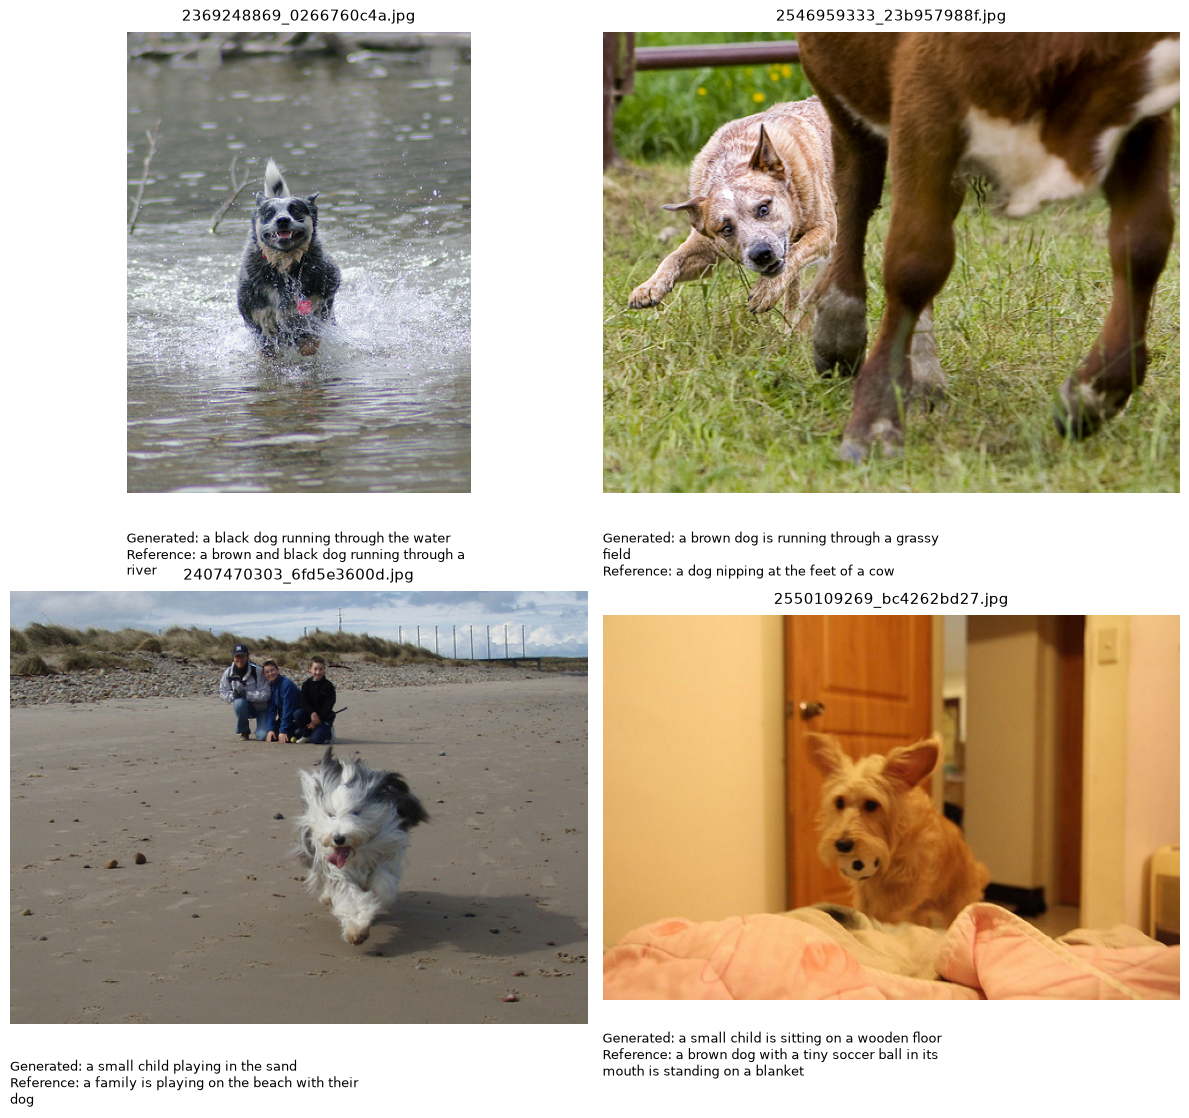

Saved contact sheet to: /Users/emanuelklatzer/Projects/03_TUW/DL_image-captioning-project/outputs/evaluation/results_slide_qualitative_examples.png
Copied individual images to:
- /Users/emanuelklatzer/Projects/03_TUW/DL_image-captioning-project/outputs/evaluation/example_images/01_2369248869_0266760c4a.jpg
- /Users/emanuelklatzer/Projects/03_TUW/DL_image-captioning-project/outputs/evaluation/example_images/02_2546959333_23b957988f.jpg
- /Users/emanuelklatzer/Projects/03_TUW/DL_image-captioning-project/outputs/evaluation/example_images/03_2407470303_6fd5e3600d.jpg
- /Users/emanuelklatzer/Projects/03_TUW/DL_image-captioning-project/outputs/evaluation/example_images/04_2550109269_bc4262bd27.jpg


In [12]:
examples_dir = EVALUATION_DIR / "example_images"
examples_dir.mkdir(parents=True, exist_ok=True)

copied_image_paths = []
for idx, row in selected_examples.iterrows():
    source_path = images_dir / row["image"]
    destination_path = examples_dir / f"{idx + 1:02d}_{row['image']}"
    shutil.copy2(source_path, destination_path)
    copied_image_paths.append(destination_path)

if len(selected_examples) == 0:
    raise ValueError("No qualitative examples selected. Check generated captions.")

columns = 2
rows = math.ceil(len(selected_examples) / columns)
fig, axes = plt.subplots(rows, columns, figsize=(12, 5.5 * rows))
axes = np.array(axes).reshape(-1)

for ax, (_, row) in zip(axes, selected_examples.iterrows()):
    image = Image.open(images_dir / row["image"]).convert("RGB")
    ax.imshow(image)
    ax.axis("off")
    title = row["image"]
    generated = textwrap.fill("Generated: " + row["generated"], width=55)
    reference = textwrap.fill("Reference: " + row["reference_1"], width=55)
    ax.set_title(title, fontsize=11, pad=8)
    ax.text(0.0, -0.08, generated + "\n" + reference, transform=ax.transAxes,
            fontsize=9, va="top")

for ax in axes[len(selected_examples):]:
    ax.axis("off")

plt.tight_layout()
contact_sheet_path = EVALUATION_DIR / "results_slide_qualitative_examples.png"
fig.savefig(contact_sheet_path, dpi=200, bbox_inches="tight")
plt.show()

print("Saved contact sheet to:", contact_sheet_path)
print("Copied individual images to:")
for path in copied_image_paths:
    print("-", path)

## 7. Summary

Final values for our results slide.

In [13]:
example_lines = []
for idx, row in selected_examples.head(2).iterrows():
    example_lines.append(
        f"**Example {idx + 1}: `{row['image']}`**  \n"
        f"Generated: {row['generated']}  \n"
        f"Reference: {row['reference_1']}"
    )

bleu_markdown = "| Metric | Ours | Ours (%) | Typical range |\n|---|---:|---:|---|\n"
for _, row in bleu_df.iterrows():
    bleu_markdown += (
        f"| {row['Metric']} | {row['Ours']:.4f} | "
        f"{row['Ours (%)']:.2f} | {row['Typical range']} |\n"
    )
summary_markdown = f"""
### Result Slide values

Paste the `Ours` values into the quantitative BLEU table:

{bleu_markdown}

Paste two qualitative examples from below, or choose another pair from `{examples_path.relative_to(PROJECT_ROOT)}`.

{chr(10).join(example_lines)}

Generated files:

- `{bleu_path.relative_to(PROJECT_ROOT)}`
- `{examples_path.relative_to(PROJECT_ROOT)}`
- `{contact_sheet_path.relative_to(PROJECT_ROOT)}`
- `{examples_dir.relative_to(PROJECT_ROOT)}/`
""".strip()

summary_path = EVALUATION_DIR / "results_slide_summary.md"
summary_path.write_text(summary_markdown)

display(Markdown(summary_markdown))
print("Saved summary to:", summary_path)

### Result Slide values

Paste the `Ours` values into the quantitative BLEU table:

| Metric | Ours | Ours (%) | Typical range |
|---|---:|---:|---|
| BLEU-1 | 0.5800 | 58.00 | 0.40-0.65 |
| BLEU-2 | 0.3951 | 39.51 | 0.25-0.45 |
| BLEU-3 | 0.2608 | 26.08 | 0.15-0.30 |
| BLEU-4 | 0.1716 | 17.16 | 0.08-0.20 |


Paste two qualitative examples from below, or choose another pair from `outputs/evaluation/results_slide_examples.csv`.

**Example 1: `2369248869_0266760c4a.jpg`**  
Generated: a black dog running through the water  
Reference: a brown and black dog running through a river
**Example 2: `2546959333_23b957988f.jpg`**  
Generated: a brown dog is running through a grassy field  
Reference: a dog nipping at the feet of a cow

Generated files:

- `outputs/evaluation/results_slide_bleu_scores.csv`
- `outputs/evaluation/results_slide_examples.csv`
- `outputs/evaluation/results_slide_qualitative_examples.png`
- `outputs/evaluation/example_images/`

Saved summary to: /Users/emanuelklatzer/Projects/03_TUW/DL_image-captioning-project/outputs/evaluation/results_slide_summary.md
